# Day 05：损失函数与梯度下降 —— 模型的「不爽程度」与优化

> ☀️ 第二周 · 破局与复兴 · 第 5 天

这一周我们学了很多碎片知识：
- 隐藏层：空间变换
- 激活函数：非线性
- 反向传播：梯度计算

今天把这些串起来，理解**损失函数**（模型怎么「吐槽」）和**梯度下降**（模型怎么「进步」）。

**今天的任务**：理解不同损失函数的适用场景，掌握梯度下降的核心思想。

---

## 1. 损失函数：模型的「不爽程度」

损失函数衡量模型的预测和真实值之间的差距。

**类比**：
- 损失 = 模型预测值和真实值之间的「差距」
- 就像你的 GPS 说「还有 3 公里到目的地」，实际还有 5 公里——误差就是 2 公里

模型的目标：**最小化损失**。

In [1]:
# 设置中文字体（解决 matplotlib 显示中文问题）
import matplotlib.pyplot as plt
import matplotlib
# 尝试使用系统可用的中文字体
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
except:
    pass


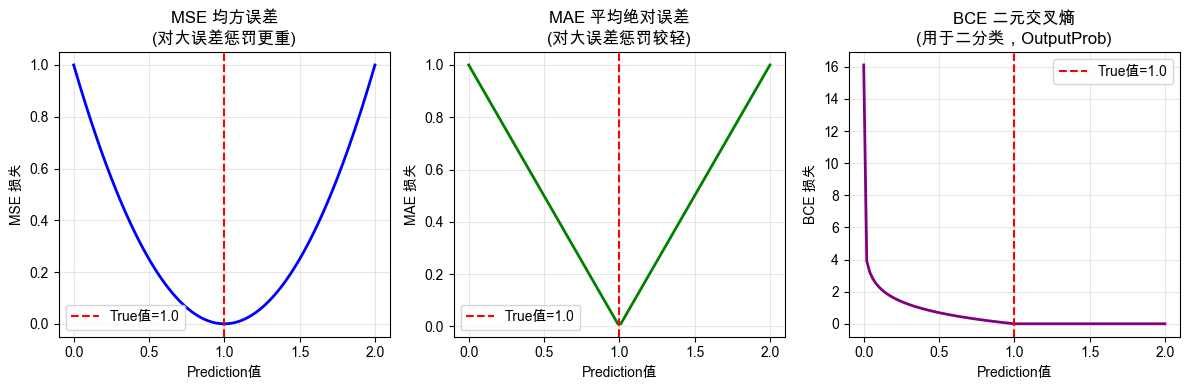


三种损失函数的对比：
| 损失函数 | 公式 | 特点 | 适用场景 |
|----------|------|------|----------|
| MSE | (y-ŷ)² | 对大误差惩罚重 | 回归任务 |
| MAE | |y-ŷ| | 对大误差惩罚轻 | 回归任务，异常值多 |
| BCE | -[ylog(ŷ)+(1-y)log(1-ŷ)] | Output是Prob | 二分类 |
| CE  | -Σ yi log(ŷi) | 多分类 | 多分类任务 |


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 假设True值
y_true = torch.tensor([1.0])

# DifferentPrediction值的 MSE
y_pred_range = torch.linspace(0, 2, 100)

def mse_loss(y_pred, y_true):
    return (y_pred - y_true)**2

def mae_loss(y_pred, y_true):
    return torch.abs(y_pred - y_true)

def bce_loss(y_pred, y_true):
    """二元交叉熵损失（用于二分类）"""
    epsilon = 1e-7  # 防止 log(0)
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
    return -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))

mse_values = [mse_loss(yp, y_true).item() for yp in y_pred_range]
mae_values = [mae_loss(yp, y_true).item() for yp in y_pred_range]
bce_values = [bce_loss(yp, y_true).item() for yp in y_pred_range]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(y_pred_range.numpy(), mse_values, 'b-', linewidth=2)
plt.axvline(x=y_true.item(), color='red', linestyle='--', label=f'True值={y_true.item()}')
plt.xlabel('Prediction值')
plt.ylabel('MSE 损失')
plt.title('MSE 均方误差\n(对大误差惩罚更重)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(y_pred_range.numpy(), mae_values, 'g-', linewidth=2)
plt.axvline(x=y_true.item(), color='red', linestyle='--', label=f'True值={y_true.item()}')
plt.xlabel('Prediction值')
plt.ylabel('MAE 损失')
plt.title('MAE 平均绝对误差\n(对大误差惩罚较轻)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(y_pred_range.numpy(), bce_values, 'purple', linewidth=2)
plt.axvline(x=y_true.item(), color='red', linestyle='--', label=f'True值={y_true.item()}')
plt.xlabel('Prediction值')
plt.ylabel('BCE 损失')
plt.title('BCE 二元交叉熵\n(用于二分类，OutputProb)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_functions_comparison.png', dpi=150)
plt.show()

print("\n三种损失函数的对比：")
print("="*60)
print("| 损失函数 | 公式 | 特点 | 适用场景 |")
print("|----------|------|------|----------|")
print("| MSE | (y-ŷ)² | 对大误差惩罚重 | 回归任务 |")
print("| MAE | |y-ŷ| | 对大误差惩罚轻 | 回归任务，异常值多 |")
print("| BCE | -[ylog(ŷ)+(1-y)log(1-ŷ)] | Output是Prob | 二分类 |")
print("| CE  | -Σ yi log(ŷi) | 多分类 | 多分类任务 |")

---

## 2. 梯度下降：模型的「学习方法」

**核心思想**：
1. 计算损失函数对每个参数的梯度
2. 沿梯度的反方向「下山」
3. 重复直到收敛

```
W_new = W_old - learning_rate × ∂L/∂W
```

类比：
- 你在山上，不知道哪条路最快下山
- 每一步，你感觉脚下的坡度（梯度）
- 你往最陡的下坡方向走
- 重复直到到达谷底

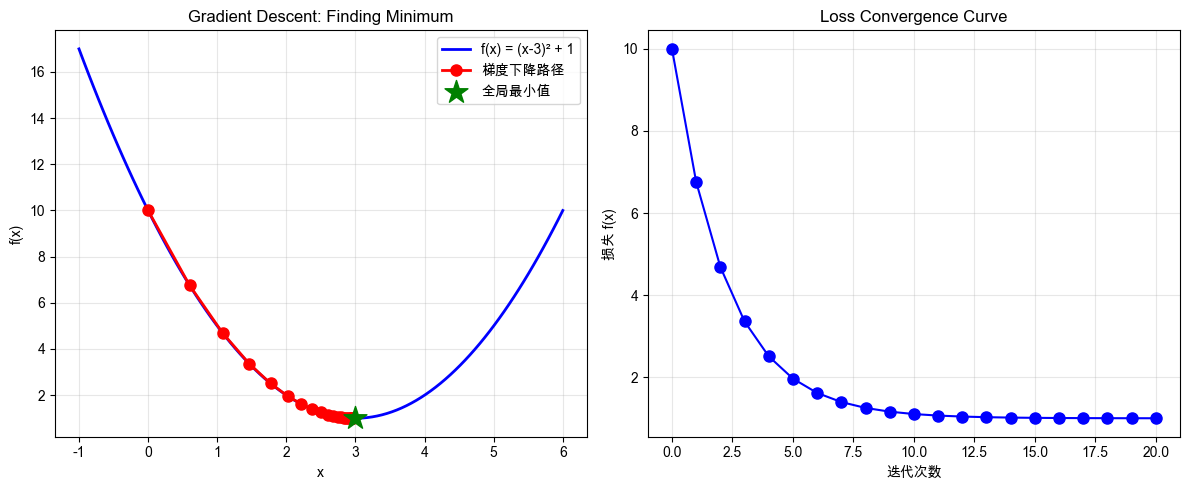


梯度下降过程：
  步 0: x = 0.0000, f(x) = 10.0000, 梯度 = -6.0000
  步 1: x = 0.6000, f(x) = 6.7600, 梯度 = -4.8000
  步 2: x = 1.0800, f(x) = 4.6864, 梯度 = -3.8400
  步 3: x = 1.4640, f(x) = 3.3593, 梯度 = -3.0720
  步 4: x = 1.7712, f(x) = 2.5099, 梯度 = -2.4576
  步 5: x = 2.0170, f(x) = 1.9664, 梯度 = -1.9661
  步 6: x = 2.2136, f(x) = 1.6185, 梯度 = -1.5729
  步 7: x = 2.3709, f(x) = 1.3958, 梯度 = -1.2583
  步 8: x = 2.4967, f(x) = 1.2533, 梯度 = -1.0066
  步 9: x = 2.5973, f(x) = 1.1621, 梯度 = -0.8053
  ... (收敛到 x ≈ 3)


In [3]:
# 可视化梯度下降
def f(x):
    """一个简单的二次函数"""
    return (x - 3)**2 + 1

def grad_f(x):
    """梯度：df/dx = 2(x - 3)"""
    return 2 * (x - 3)

# 梯度下降
x = 0.0  # 初始位置
lr = 0.1  # 学习率
trajectory = [x]

for _ in range(20):
    gradient = grad_f(x)
    x = x - lr * gradient
    trajectory.append(x)

# 可视化
x_range = np.linspace(-1, 6, 100)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_range, [f(xi) for xi in x_range], 'b-', linewidth=2, label='f(x) = (x-3)² + 1')
plt.plot(trajectory, [f(xi) for xi in trajectory], 'ro-', markersize=8, linewidth=2, label='梯度下降路径')
plt.scatter([3], [1], c='green', s=300, marker='*', zorder=5, label='全局最小值')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient Descent: Finding Minimum')
plt.legend()
plt.grid(True, alpha=0.3)

# 收敛过程
plt.subplot(1, 2, 2)
losses = [f(xi) for xi in trajectory]
plt.plot(range(len(losses)), losses, 'bo-', markersize=8)
plt.xlabel('迭代次数')
plt.ylabel('损失 f(x)')
plt.title('Loss Convergence Curve')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_descent_visualization.png', dpi=150)
plt.show()

print("\n梯度下降过程：")
for i, x in enumerate(trajectory[:10]):
    print(f"  步 {i}: x = {x:.4f}, f(x) = {f(x):.4f}, 梯度 = {grad_f(x):.4f}")
print(f"  ... (收敛到 x ≈ 3)")

---

## 3. 学习率的影响

学习率（learning rate）控制每一步走多远。

- **太大**：可能越过最小值，甚至发散
- **太小**：收敛太慢
- **刚好**：稳定收敛

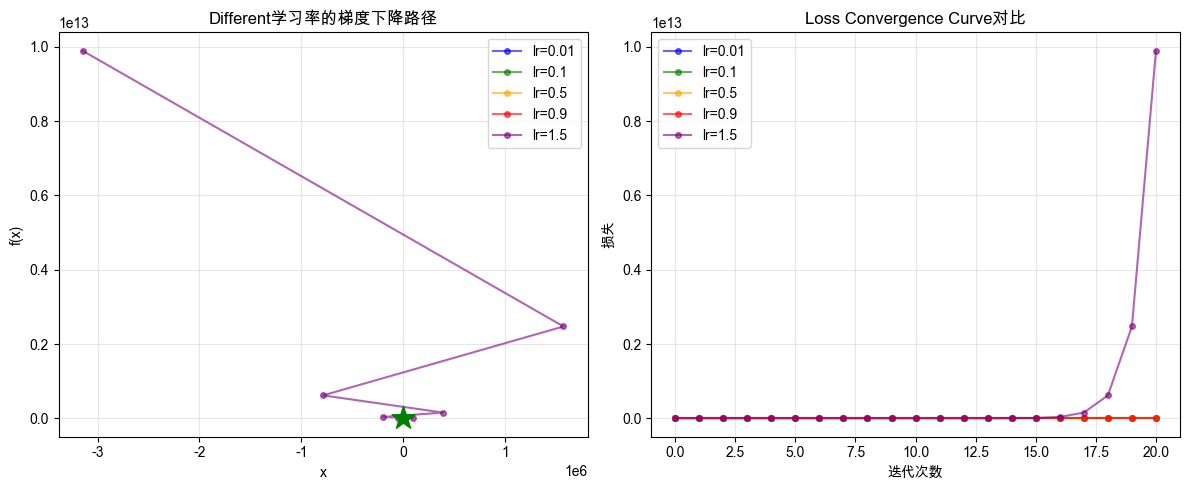


📝 Effect of Learning Rate：
   lr=0.01: Too small, converges slowly
   lr=0.1:  Just right, converges stably
   lr=0.5:  Fast, may oscillate
   lr=0.9:  Fast, but may oscillate
   lr=1.5:  Too large, diverges!


In [4]:
def gradient_descent(f, grad_f, x_init, lr, n_steps):
    """通用梯度下降函数"""
    x = x_init
    trajectory = [x]
    for _ in range(n_steps):
        gradient = grad_f(x)
        x = x - lr * gradient
        trajectory.append(x)
    return trajectory

# Different学习率的对比
learning_rates = [0.01, 0.1, 0.5, 0.9, 1.5]
colors = ['blue', 'green', 'orange', 'red', 'purple']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
x_range = np.linspace(-1, 6, 100)
plt.plot(x_range, [f(xi) for xi in x_range], 'k-', linewidth=2)
plt.scatter([3], [1], c='green', s=300, marker='*', zorder=5)

for lr, color in zip(learning_rates, colors):
    traj = gradient_descent(f, grad_f, x_init=0.0, lr=lr, n_steps=20)
    plt.plot(traj, [f(xi) for xi in traj], 'o-', color=color, alpha=0.6, 
             markersize=4, label=f'lr={lr}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Different学习率的梯度下降路径')
plt.legend()
plt.grid(True, alpha=0.3)

# 收敛曲线
plt.subplot(1, 2, 2)
for lr, color in zip(learning_rates, colors):
    traj = gradient_descent(f, grad_f, x_init=0.0, lr=lr, n_steps=20)
    losses = [f(xi) for xi in traj]
    plt.plot(range(len(losses)), losses, 'o-', color=color, alpha=0.6, 
             markersize=4, label=f'lr={lr}')

plt.xlabel('迭代次数')
plt.ylabel('损失')
plt.title('Loss Convergence Curve对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rate_comparison.png', dpi=150)
plt.show()

print("\n📝 Effect of Learning Rate：")
print("   lr=0.01: Too small, converges slowly")
print("   lr=0.1:  Just right, converges stably")
print("   lr=0.5:  Fast, may oscillate")
print("   lr=0.9:  Fast, but may oscillate")
print("   lr=1.5:  Too large, diverges!")

---

## 4. 优化器对比：SGD vs Adam

PyTorch 提供了多种优化器：

| 优化器 | 原理 | 特点 |
|--------|------|------|
| SGD | 随机梯度下降 | 简单，但可能震荡 |
| SGD + Momentum | 加上惯性 | 减少震荡，加速收敛 |
| Adam | 自适应学习率 | 适合大多数场景，默认首选 |

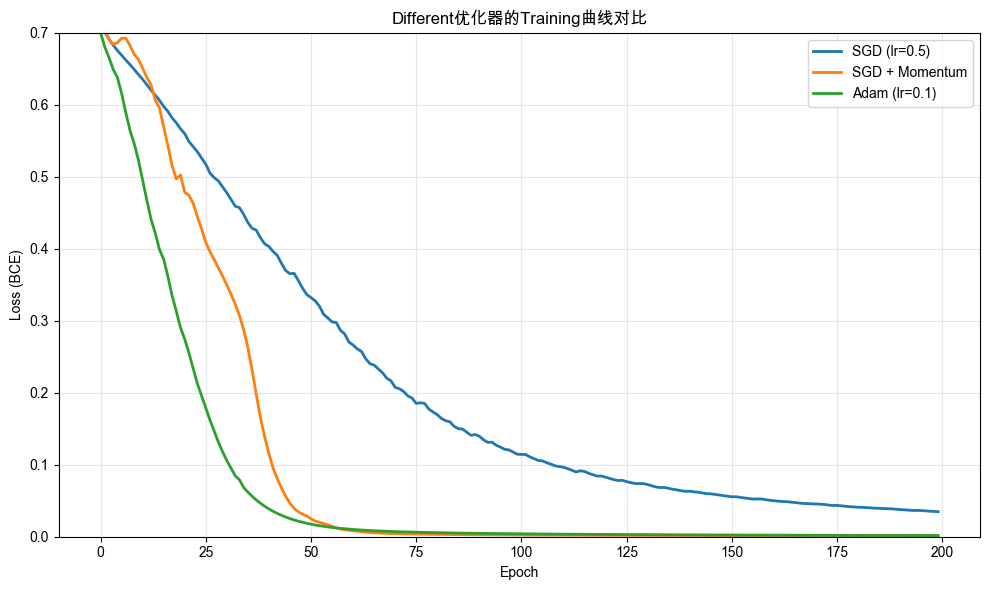


📝 优化器选择建议：
   Adam: 大多数情况下的首选，自适应学习率
   SGD + Momentum: 喜欢精调的工程师常用，效果可能更好
   SGD: 简单场景或大规模分布式Training


In [5]:
import torch

# 准备数据
X = torch.tensor([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [1.0, 1.0]], dtype=torch.float32)
y = torch.tensor([[1.0], [0.0], [0.0], [1.0]], dtype=torch.float32)

# 定义 MLP
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, 1),
            torch.nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

criterion = torch.nn.BCELoss()

# Different优化器对比
results = {}

# SGD
mlp_sgd = MLP()
optimizer_sgd = torch.optim.SGD(mlp_sgd.parameters(), lr=0.5)
losses_sgd = []
for epoch in range(200):
    optimizer_sgd.zero_grad()
    y_pred = mlp_sgd(X)
    loss = criterion(y_pred, y)
    losses_sgd.append(loss.item())
    loss.backward()
    optimizer_sgd.step()
results['SGD (lr=0.5)'] = losses_sgd

# SGD + Momentum
mlp_momentum = MLP()
optimizer_momentum = torch.optim.SGD(mlp_momentum.parameters(), lr=0.5, momentum=0.9)
losses_momentum = []
for epoch in range(200):
    optimizer_momentum.zero_grad()
    y_pred = mlp_momentum(X)
    loss = criterion(y_pred, y)
    losses_momentum.append(loss.item())
    loss.backward()
    optimizer_momentum.step()
results['SGD + Momentum'] = losses_momentum

# Adam
mlp_adam = MLP()
optimizer_adam = torch.optim.Adam(mlp_adam.parameters(), lr=0.1)
losses_adam = []
for epoch in range(200):
    optimizer_adam.zero_grad()
    y_pred = mlp_adam(X)
    loss = criterion(y_pred, y)
    losses_adam.append(loss.item())
    loss.backward()
    optimizer_adam.step()
results['Adam (lr=0.1)'] = losses_adam

# 可视化
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for name, losses in results.items():
    plt.plot(losses, label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('Different优化器的Training曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

print("\n📝 优化器选择建议：")
print("   Adam: 大多数情况下的首选，自适应学习率")
print("   SGD + Momentum: 喜欢精调的工程师常用，效果可能更好")
print("   SGD: 简单场景或大规模分布式Training")


---

## 5. 实战：用完整训练流程解决 XOR

In [6]:
import torch

# 完整的Training流程
def train_xor(mlp, optimizer, criterion, X, y, epochs=500):
    """Complete Training Pipeline"""
    losses = []
    for epoch in range(epochs):
        # 1. 前向传播
        y_pred = mlp(X)
        
        # 2. 计算损失
        loss = criterion(y_pred, y)
        losses.append(loss.item())
        
        # 3. 清零梯度
        optimizer.zero_grad()
        
        # 4. 反向传播
        loss.backward()
        
        # 5. 更新参数
        optimizer.step()
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}: Loss = {loss.item():.4f}")
    
    return losses

# 创建模型
mlp = MLP()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.3)
criterion = torch.nn.BCELoss()

print("Training MLP 解决 XOR...")
print("="*50)
losses = train_xor(mlp, optimizer, criterion, X, y)

# Test
print("\nPrediction Results:")
mlp.eval()
with torch.no_grad():
    y_pred = mlp(X)
    
for i in range(4):
    x_str = f"({int(X[i,0].item())}, {int(X[i,1].item())})"
    true_val = int(y[i].item())
    pred_prob = y_pred[i].item()
    pred_val = 1 if pred_prob > 0.5 else 0
    status = "✓" if true_val == pred_val else "✗"
    print(f"  {x_str}: True={true_val}, Prediction={pred_val} (Prob={pred_prob:.4f}) {status}")

Training MLP 解决 XOR...
  Epoch 100: Loss = 0.4774
  Epoch 200: Loss = 0.4774
  Epoch 300: Loss = 0.4774
  Epoch 400: Loss = 0.4774
  Epoch 500: Loss = 0.4774

Prediction Results:
  (0, 0): True=1, Prediction=1 (Prob=0.6667) ✓
  (1, 0): True=0, Prediction=1 (Prob=0.6667) ✗
  (0, 1): True=0, Prediction=0 (Prob=0.0000) ✓
  (1, 1): True=1, Prediction=1 (Prob=0.6667) ✓


---

## 6. 局部最小值与鞍点

梯度下降不保证找到全局最小值。可能卡在**局部最小值**或**鞍点**。

```
         ╭─╮
        ╱   ╲           ← 局部最小值
   ───╯     ╰────
              ╲     ╱
               ╲   ╱
                ╲ ╱
                 ╳   ← 鞍点（一个方向向下，一个方向向上）
                ╱ ╲
               ╱   ╲
   ────────────────────  全局最小值方向
```

**好消息**：对于 MLP 这种高维问题，局部最小值通常也够好。

/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_1171/576652549.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gx, gy = grad_saddle(torch.tensor(x), torch.tensor(y))


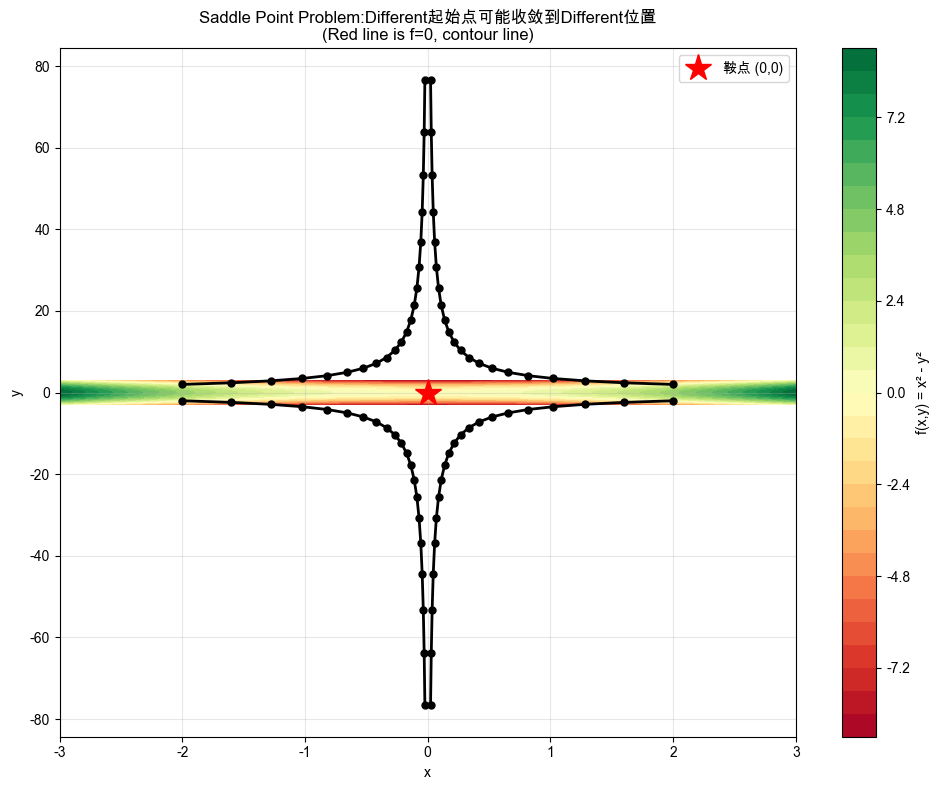


📝 Saddle Point Problem:
   - At saddle point, gradient is nearly zero, but this is a local max/min
   - Different起始点可能收敛到Different位置
   - Modern optimizers (Adam) usually handle this better


In [7]:
# Demonstrating Saddle Point Problem
def saddle_function(x, y):
    """鞍点函数：f(x,y) = x² - y²"""
    return x**2 - y**2

def grad_saddle(x, y):
    """梯度"""
    return torch.tensor([2*x, -2*y])

# Different起始点的轨迹
starts = [(2, 2), (2, -2), (-2, 2), (-2, -2)]
lr = 0.1

x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z = X_mesh**2 - Y_mesh**2

plt.figure(figsize=(10, 8))
contour = plt.contourf(X_mesh, Y_mesh, Z, levels=30, cmap='RdYlGn')
plt.colorbar(contour, label='f(x,y) = x² - y²')

for start_x, start_y in starts:
    x, y = float(start_x), float(start_y)
    traj_x = [x]
    traj_y = [y]
    
    for _ in range(20):
        gx, gy = grad_saddle(torch.tensor(x), torch.tensor(y))
        x = x - lr * gx
        y = y - lr * gy
        traj_x.append(x)
        traj_y.append(y)
    
    plt.plot(traj_x, traj_y, 'ko-', markersize=5, linewidth=2)

plt.plot(0, 0, 'r*', markersize=20, label='鞍点 (0,0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Saddle Point Problem:Different起始点可能收敛到Different位置\n(Red line is f=0, contour line)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('saddle_point_problem.png', dpi=150)
plt.show()

print("\n📝 Saddle Point Problem:")
print("   - At saddle point, gradient is nearly zero, but this is a local max/min")
print("   - Different起始点可能收敛到Different位置")
print("   - Modern optimizers (Adam) usually handle this better")

---

## 今日总结

| 概念 | 含义 | 选择建议 |
|------|------|----------|
| MSE | 均方误差，对大误差惩罚重 | 回归任务 |
| MAE | 平均绝对误差，对异常值鲁棒 | 回归任务 |
| BCE | 二元交叉熵，输出概率 | 二分类 |
| CE | 交叉熵 | 多分类 |

| 优化器 | 特点 | 场景 |
|--------|------|------|
| SGD | 简单，稳定 | 大规模训练 |
| SGD+Momentum | 减少震荡，加速 | 精调时用 |
| Adam | 自适应学习率，默认首选 | 绝大多数场景 |

**关键参数**：
- **学习率**：最重要，通常 0.001 ~ 0.1
- **Batch size**：影响梯度估计的稳定性
- **Epoch 数**：太多会过拟合，太少欠拟合

---

## 第二周总结

这一周我们学习了神经网络的核心组件：

| 天 | 主题 | 核心概念 |
|----|------|----------|
| Day01 | 隐藏层 | 空间变换，线性不可分 → 线性可分 |
| Day02 | 激活函数 | Sigmoid/ReLU，非线性 + 可导 |
| Day03 | 反向传播 | 链式法则，信用分配 |
| Day04 | MLP 训练 | PyTorch autograd，完整训练流程 |
| Day05 | 损失函数与优化 | MSE/BCE，梯度下降，Adam |

**下周预告**：进入视觉领域！学习**卷积神经网络（CNN）**——如何让机器「看见」图片。